# Estimating Air Volume in a Mussel Shell

This notebook will showcase a method for calculating the volume of the air inside of a mussel from a µCT-scan.
For this, the `qim3d` library will be showcased and used.


First, the `qim3d` library is imported:

In [19]:
import qim3d

## 1. 📂 Loading the data
The `qim3d` library's `io.Downloader()` is used to load in the mussel volumetric data from the QIM data repository:

In [ ]:
downloader = qim3d.io.Downloader()
data = downloader.Mussel.ClosedMussel1(load_file=True)

The volume is converted to the OME-Zarr format to enable faster, more memory-efficient analysis by working with a chunked, multiscale version of the volume that is optimized for on-demand access. The `qim3d` library's `io.export_ome_zarr()` converts the volume to this format and exports it:


In [ ]:
qim3d.io.export_ome_zarr("Mussel.zarr", data, chunk_size=100, downsample_rate=2, replace=True)

Now, the OME-Zarr volume is loaded in:

In [29]:
volume = qim3d.io.import_ome_zarr("Mussel.zarr", scale=2, load=True)

Data contains 5 scales:
- Scale 0: (600, 1000, 1000)
- Scale 1: (300, 500, 500)
- Scale 2: (150, 250, 250)
- Scale 3: (75, 125, 125)
- Scale 4: (38, 62, 62)

Loading scale 2 with shape (150, 250, 250)


## 2. 🔍 Exploring the data

The mussel can now be visualized using `qim3d`'s `viz.volumetric()`. The minimum and maximum intensities have been adjusted interactively in the rendering until the result was visually pleasing, after which the values were passed into the function. A list of available colormaps can be found at the __[matplotlib docs](https://matplotlib.org/stable/users/explain/colors/colormaps.html)__. The resulting visualziation can be seen below:

In [ ]:
qim3d.viz.volumetric(volume, vmin=70, vmax=150, color_map='Blues')

<img src="./screenshots/mussel_visualization.gif" alt="Mussel Visualization" width="800">

Equidistant slices of the mussel µCT-scan can be viewed using `qim3d`'s `viz.slices_grid()`. Here 15 slices are chosen:

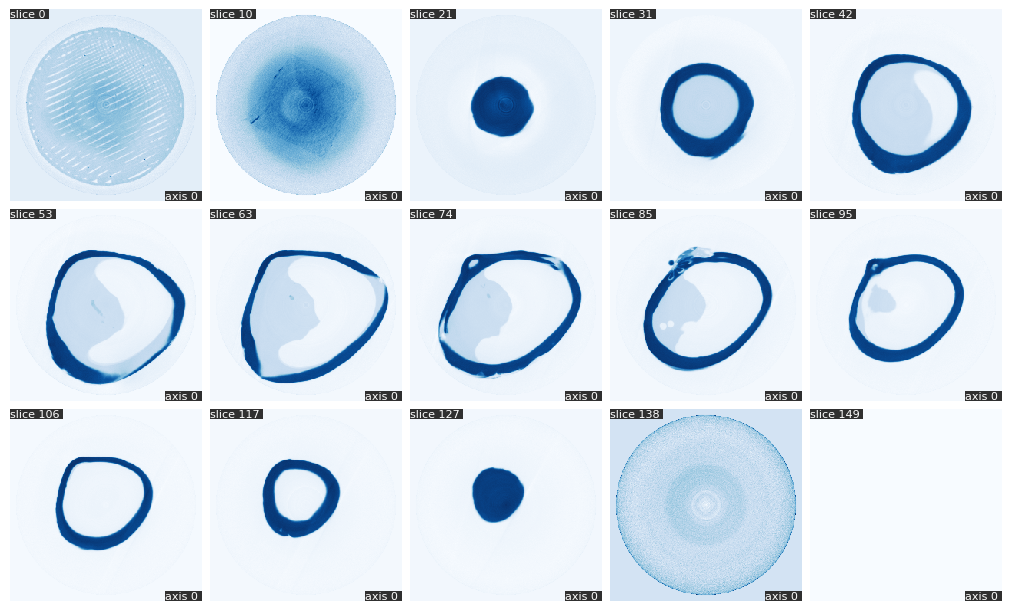

In [6]:
qim3d.viz.slices_grid(volume, num_slices=15, color_map='Blues')

In these slices we see the outer shell (dark blue), air (very light blue / white), and soft tissue (blue). We're interested in segmenting out the air, meaning the very light parts on the inside of the shell.

## 3. 💨 Segmenting Air Pocket

To segmenting out the air, we first threshold the volume. To do this, `qim3d`'s `viz.threshold()` is a great tool as it allows for interactive thresholding:

In [ ]:
qim3d.viz.threshold(volume, cmap_image='Blues')

<img src="./screenshots/mussel_thresholding.png" alt="Mussel Visualization" width="1000">

After exploring the options, the threshold of voxel intensity 15 - found using mean thresholding - looked to correctly segment out air from shell and soft tissue. This threshold is now applied to the volume in order to create a binary volume:

In [30]:
bin_vol = volume > 15

In a moment, watershed will be used to segment out the inner air pocket in the volume. In order for this to happen, the binary volume must be inverted, meaning 1's and 0's swap. This is done by:

In [31]:
bin_vol = 1 - bin_vol

Now, watershed segmentation is applied to the binary volume. This is done using `qim3d`'s `segmentation.watershed()` on the binary volume. A `minimum_distance` of 40 is chosen, as we know that we are only looking for very few different segments:

Total number of objects found: 8


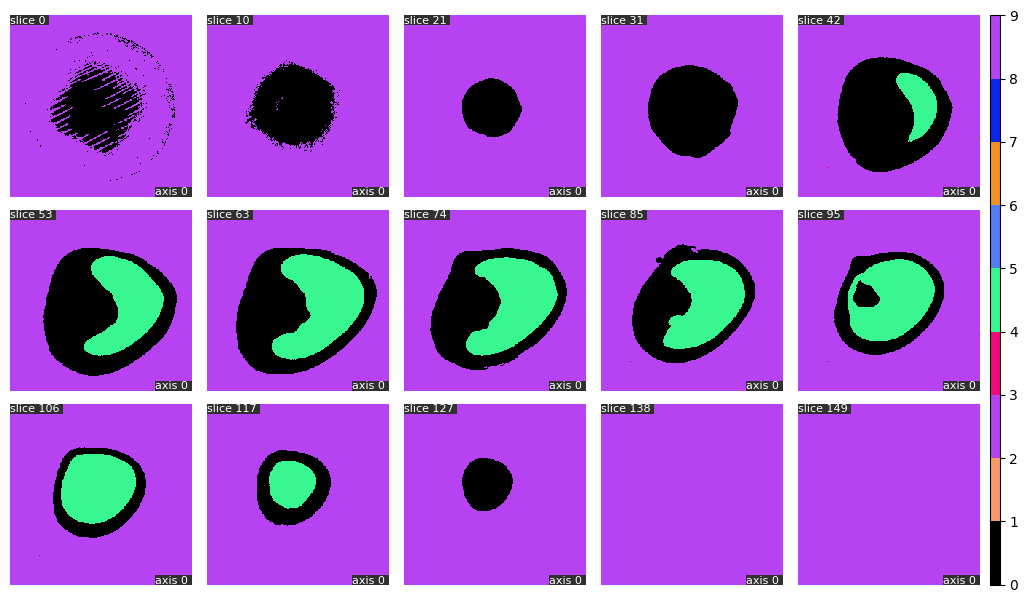

In [10]:
labeled_volume, num_labels = qim3d.segmentation.watershed(bin_vol, min_distance=40)
cmap = qim3d.viz.colormaps.segmentation(num_labels)
fig2 = qim3d.viz.slices_grid(labeled_volume, slice_axis=0, color_map=cmap, display_figure=True, color_bar=True, color_bar_style='large')

It can be seen, that the inner air pocket has a value of 4 in the labelled volume (green). Therefore, a new mask of the inner air pocket is created:

In [36]:
vol_air = (labeled_volume == 4)

For illustrative purposes, a copy of the original volume is created. In this volume, the inner air pocket voxels are given an intensity slightly larger than the largest in the volume:

In [37]:
volume_copy = volume.copy()
volume_copy[vol_air == 1] = volume_copy.max() + 50

This new volume is now visualized, in order to see the air pocket fitting nicely inside of the shell:

In [ ]:
qim3d.viz.volumetric(volume_copy, vmin=10, color_map='Blues')

<img src="./screenshots/mussel_air_visualization.gif" alt="Mussel Visualization" width="800">

## 4. 🕸️ Surface Mesh Generation

The binary volume of the air pocket can now be turned into a mesh, encapsuling the air pocket. This is done using `qim3d`'s `mesh.from_volume()`, after which the mesh is rendered using `qim3d`'s `viz.mesh()`:

In [ ]:
mesh = qim3d.mesh.from_volume(vol_air)
qim3d.viz.mesh(mesh)

<img src="./screenshots/mussel_mesh.gif" alt="Mussel Visualization" width="800">

The volume of this mesh can now be calculated using `qim3d`'s `features.volume()`:

In [41]:
volume_air = qim3d.features.volume(mesh)
print(f"Volume of air: {volume_air}")

Volume of air: 691146.807385624


This is, however, not in a real world unit. 


If the volume resolution is isotropic, meaning the voxel resolution is identical along all axes, the volume can easily be converted into mm³. Given a resolution in $\frac{\text{mm}}{\text{voxel}}$, the volume in mm³ is calculated in the following way:

In [43]:
resolution = 0.0211 # Enter your value (mm/voxel)
scaling_factor = resolution**3
volume_world = volume_air * scaling_factor
print(f"Total air volume: {volume_world} mm³")

Total air volume: 6.492585419450844 mm³


The resolution of volumes from the QIM Data Repository can be found at __[data.qim.dk](https://data.qim.dk)__. For the mussel specifically, it can be found __[here](https://data.qim.dk/pages/mussel.html)__.